# Sales Data Analysis & Dashboard

## Objective
Analyze e-commerce sales data to identify trends, top-performing categories, and regional performance to support business decision-making.

In [22]:
import pandas as pd

df = pd.read_csv("../data/Amazon Sale Report.csv", low_memory=False)

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [27]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 109696 entries, 1 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               109696 non-null  int64         
 1   Order ID            109696 non-null  object        
 2   Date                109696 non-null  datetime64[ns]
 3   Status              109696 non-null  object        
 4   Fulfilment          109696 non-null  object        
 5   Sales Channel       109696 non-null  object        
 6   ship-service-level  109696 non-null  object        
 7   Style               109696 non-null  object        
 8   SKU                 109696 non-null  object        
 9   Category            109696 non-null  object        
 10  Size                109696 non-null  object        
 11  ASIN                109696 non-null  object        
 12  Courier Status      109685 non-null  object        
 13  Qty                 109696 non-nul

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status           11
Qty                       0
currency                219
Amount                  219
ship-city                26
ship-state               26
ship-postal-code         26
ship-country             26
promotion-ids         30953
B2B                       0
fulfilled-by          77804
Unnamed: 22           41925
dtype: int64

In [28]:
df.drop(columns=["index", "Unnamed: 22", "promotion-ids", "fulfilled-by"], inplace=True)

In [29]:
df = df[df["Amount"].notnull()]

df["Courier Status"] = df["Courier Status"].fillna("Unknown")
df["ship-city"] = df["ship-city"].fillna("Unknown")
df["ship-state"] = df["ship-state"].fillna("Unknown")

In [30]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df = df[df["Status"].str.contains("Shipped", na=False)]

In [31]:
df.columns = df.columns.str.strip()
df_clean = df[[
    "Date", "Category", "Amount", "Qty",
    "ship-state", "ship-city", "Sales Channel"
]]

In [32]:
df_clean["Amount"].sum()

np.float64(71050985.0)

## Total Revenue

### Insight:
The dataset generated approximately ₹7.1M in total revenue from shipped orders, indicating strong overall sales performance.

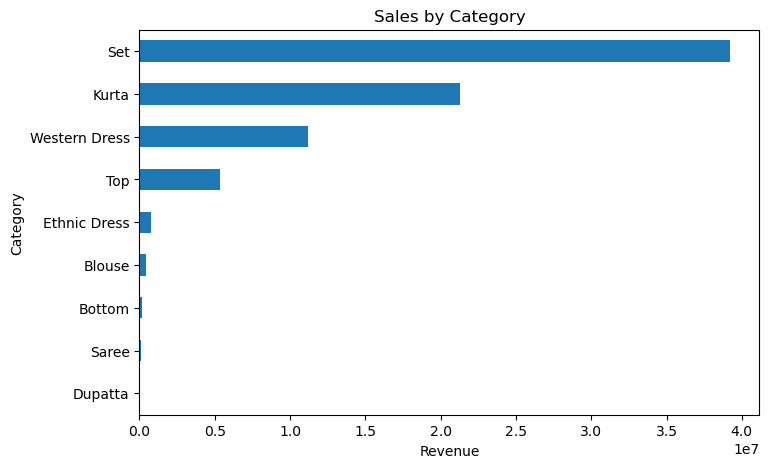

In [24]:
df_clean = df_clean.copy()
df_clean.loc[:, "Category"] = df_clean["Category"].str.title()
df_clean.groupby("Category")["Amount"].sum().sort_values().plot(
    kind="barh", figsize=(8,5)
)
plt.title("Sales by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

## Sales by Category

### Insight:
The "Set" category generates the highest revenue, followed by "Kurta", indicating strong customer preference for these product segments. Revenue is heavily concentrated in the top categories, while others contribute significantly less.

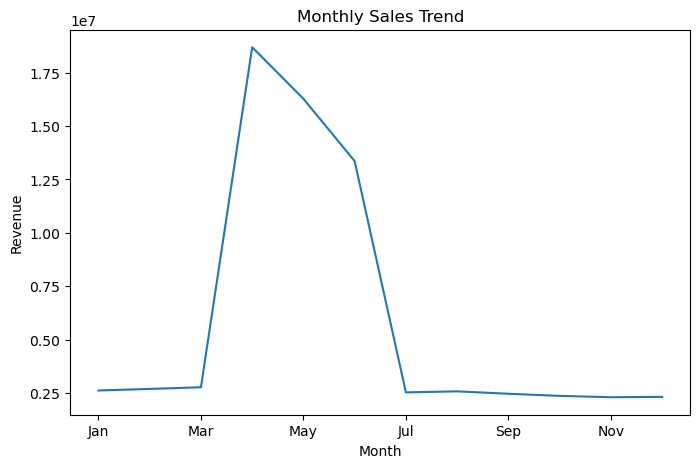

In [36]:
df_clean = df_clean.copy()

df_clean["Date"] = pd.to_datetime(df_clean["Date"], dayfirst=True, errors="coerce")
df_clean = df_clean[df_clean["Date"].notnull()]

df_clean["Month"] = df_clean["Date"].dt.strftime("%b")

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
df_clean["Month"] = pd.Categorical(df_clean["Month"], categories=month_order, ordered=True)

monthly_sales = df_clean.groupby("Month", observed=False)["Amount"].sum()

monthly_sales.plot(figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Monthly Sales Trend

### Insight:
Sales peak significantly during April and May, indicating strong seasonal demand during this period. Revenue declines sharply after June, suggesting the end of peak sales season or reduced customer activity in later months.

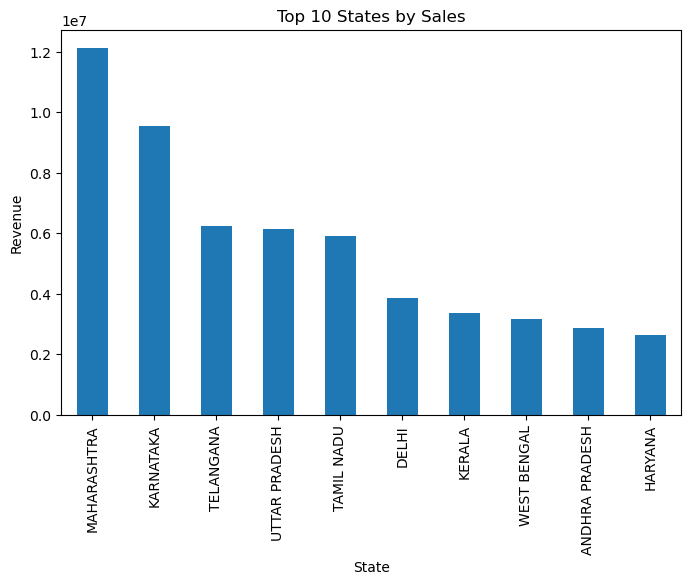

In [37]:
df_clean.groupby("ship-state")["Amount"].sum() \
    .sort_values(ascending=False).head(10) \
    .plot(kind="bar", figsize=(8,5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

## Regional Analysis

### Insight:
Maharashtra generates the highest revenue, followed by Karnataka and Telangana, indicating strong demand in major metropolitan and high-population states. Sales are concentrated in key regions, suggesting potential opportunities for expansion in lower-performing areas.

## Key Insights

- Total revenue exceeded ₹7.1M from shipped orders
- "Set" and "Kurta" are the top-performing product categories
- Sales peak during April–May, indicating strong seasonal demand
- Maharashtra and Karnataka are the highest revenue-generating states